In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng()

In [4]:
def force_left(k, L, x, y):

    if x < 0:
        force = -k*x
    else:
        force = 0

    return force

In [5]:
def force_right(k, L, x, y):

    if x > L:
        force = -k*(x - L)
    else:
        force = 0

    return force

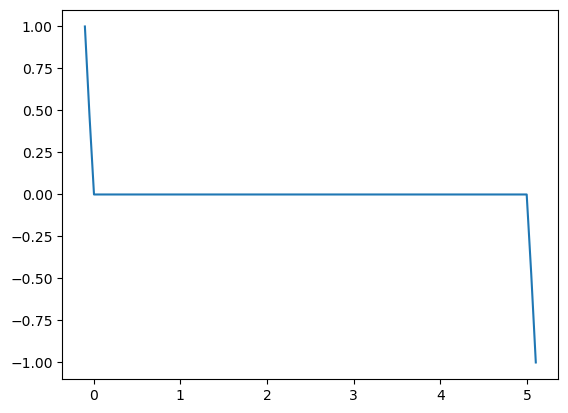

In [6]:
xarr = np.linspace(-0.1, 5.1, 100)
yarr = np.array([])
for i in range(len(xarr)):
    yarr = np.append(yarr, force_left(10, 5, xarr[i], 0) + force_right(10, 5, xarr[i], 0))
plt.plot(xarr, yarr)

In [7]:
def euler_maruyama_step(k, w, D_r, L, delta_t, x_t, y_t, theta_t):
    
    x_tpdt = x_t + np.cos(theta_t)*delta_t + (force_left(k, L, x_t, y_t) + force_right(k, L, x_t, y_t))*delta_t
    y_tpdt = y_t + np.sin(theta_t)*delta_t

    d_beta = rng.normal(0, np.sqrt(delta_t))
    theta_tpdt = theta_t + (1 + w)*delta_t + (force_left(k, L, x_t, y_t) + 
                                      force_right(k, L, x_t, y_t))*np.cos(theta_t)*delta_t + np.sqrt(2*D_r)*d_beta

    return x_tpdt, y_tpdt, theta_tpdt

In [8]:
def particle_trajectory(k, w, D_r, L, delta_t, N, x0, y0, theta0):
    
    x = x0
    y = y0
    theta = theta0
    #x_array = np.array([x])
    x_array = np.zeros(N)
    #y_array = np.array([y])
    y_array = np.zeros(N)
    #theta_array = np.array([theta])
    theta_array = np.zeros(N)
    x_array[0] = x0
    y_array[0] = y0
    theta_array[0] = theta0
    tot_steps = 1

    while tot_steps < N:
        x, y, theta = euler_maruyama_step(k, w, D_r, L, delta_t, x, y, theta)
    
        x_array[tot_steps] = x
        y_array[tot_steps] = y
        theta_array[tot_steps] = theta
        tot_steps += 1 
        if y > L/2:
            y = -L/2 + (y - L/2)
        if y < -L/2:
            y = L/2 + (y + L/2)

    return x_array, y_array, theta_array

In [9]:
x, y, t = particle_trajectory(15, -0.3, 0.3, 2.0, 0.01, 15*45000, 1.0, 0.0, 0)

In [10]:
diffs = np.append(np.diff(y), 0)
discont_indices = np.abs(diffs) > 1
y[discont_indices] = np.nan

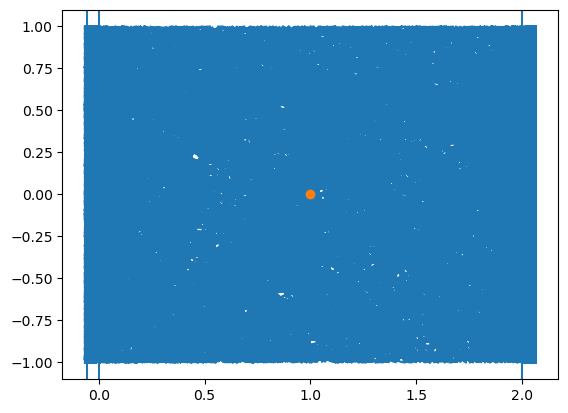

In [11]:
plt.plot(x, y)
plt.plot(1, 0, 'o')
plt.axvline(0)
plt.axvline(2.0)

plt.axvline(-np.sqrt(1-0.3)/15)

#plt.savefig('accumulation')

In [12]:
print(np.min(x))
print(-np.sqrt(1-0.3)/15)
print(np.sin(t[-1]))

-0.06659898017320162
-0.0557773351022717
-0.7401550873110445


In [36]:
omega_array = np.array([-0.2, -0.3, -0.35, -0.40, -0.45, -0.50, -0.60, -0.80])
k_array = np.array([5, 7.5, 10, 12.5, 15, 17.5, 20])
len_om = len(omega_array)
len_k = len(k_array)

penetration_grid = np.zeros((len_om, len_k))

for j in range(len_om):
    for i in range(len_k):
        x, y, t = particle_trajectory(k_array[i], omega_array[j], 0.8, 2.0, 0.01, 10*45000, 1.0, 0.0, 0)
        penetration_grid[j][i] = np.min(x)

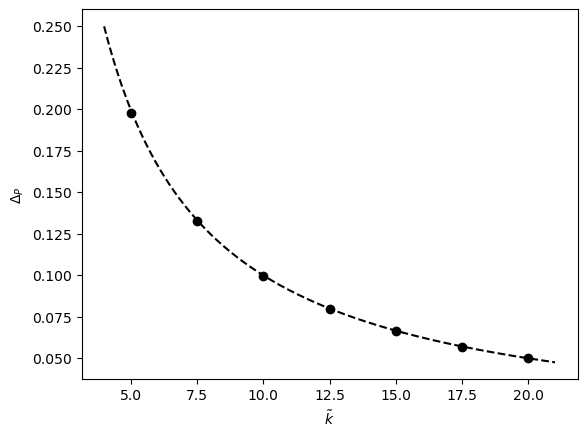

In [76]:
ka = np.linspace(4, 21, 1000)
pen = -1/ka

plt.plot(ka, -pen, color = 'black', linestyle = '--')
plt.plot(k_array, -penetration_grid[7], 'o', color = 'black')
plt.xlabel(r'$\tilde{k}$')
plt.ylabel(r'$\Delta_P$')

plt.savefig('chiral_penetration')

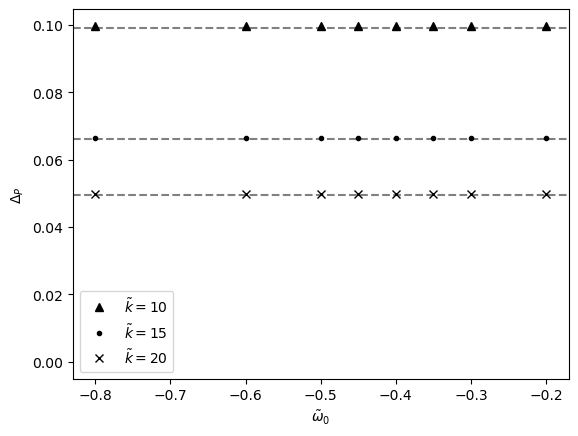

In [75]:
#plt.axhline(0.99/5, linestyle = '--', color = 'grey')
plt.axhline(0.99/10, linestyle = '--', color = 'grey')
plt.axhline(0.99/15, linestyle = '--', color = 'grey')
plt.axhline(0.99/20, linestyle = '--', color = 'grey')
plt.axhline(0, linestyle = '--', color = 'white')
#plt.plot(omega_array, -penetration_grid[:,0], 's', color = 'black', label = r'$\tilde{k} = 5$')
plt.plot(omega_array, -penetration_grid[:,2], '^', color = 'black', label = r'$\tilde{k} = 10$')
plt.plot(omega_array, -penetration_grid[:,4], '.', color = 'black', label = r'$\tilde{k} = 15$')
plt.plot(omega_array, -penetration_grid[:,6], 'x', color = 'black', label = r'$\tilde{k} = 20$')
plt.xlabel(r'$\tilde{\omega}_0$')
plt.ylabel(r'$\Delta_P$')
plt.legend()

plt.savefig('chiral_pen_indep')

In [77]:
N_bins = 20

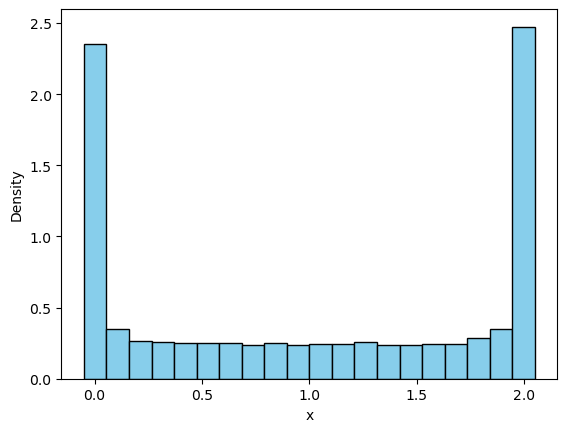

In [78]:
plt.hist(x, bins = N_bins, density = True, color = 'skyblue', edgecolor = 'black')
plt.xlabel('x')
plt.ylabel('Density')

ax = plt.gca()

plt.savefig('Density_distribution')

In [79]:
p = ax.patches
prob_distr = np.array([])
for i in range(N_bins):
    prob_distr = np.append(prob_distr, p[i].get_width()*p[i].get_height())

print(np.sum(prob_distr))

1.0


In [80]:
P_edge = 0
for i in range(N_bins):
    P_edge += np.abs(prob_distr[i] - 1/N_bins)

P_edge = P_edge/4

In [81]:
P_bulk_d = (1 - P_edge)/N_bins
P_bulk_c = P_bulk_d/p[0].get_width()

In [82]:
kappa = P_edge/P_bulk_c
print(kappa)

0.5357943829265117


In [106]:
ax.clear()

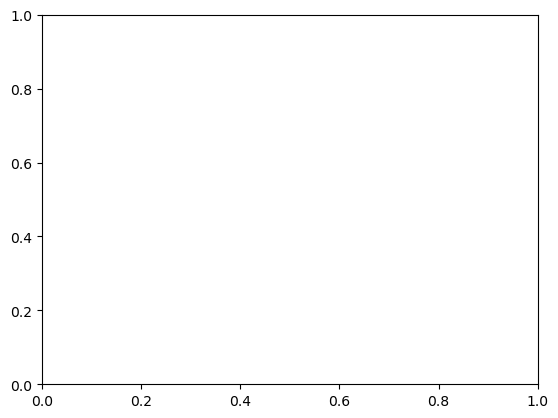

In [170]:
L_array = np.array([2.0, 3.0, 7.0, 11.0, 13.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0])
om_arr = np.array([-0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9])
kappa_array = np.zeros((len(om_arr), len(L_array)))
for j in range(len(om_arr)):
    for i in range(len(L_array)):
        x, y, t = particle_trajectory(10, om_arr[j], 0.3, L_array[i], 0.01, 80*50000, L_array[i]/2, 0.0, 0)
        plt.hist(x, bins = int(L_array[i]/0.1), density = True, color = 'skyblue', edgecolor = 'black')
        ax = plt.gca()
        p = ax.patches
        prob_distr = np.array([])
        for k in range(N_bins):
            prob_distr = np.append(prob_distr, p[k].get_width()*p[k].get_height())
        P_edge = 0
        for k in range(N_bins):
            P_edge += 0.5*np.abs(prob_distr[k] - 1/N_bins)
        P_edge = P_edge/4
        P_bulk_d = (1 - P_edge)/N_bins
        P_bulk_c = P_bulk_d/p[0].get_width()
        kappa = P_edge/P_bulk_c
        kappa_array[j][i] = kappa 
        ax.clear()

In [171]:
print(kappa_array)

[[0.27709788 0.19906859 0.2242339  0.23390355 0.24240082 0.24913887
  0.25635996 0.26131997 0.26203303 0.26810776 0.2692511 ]
 [0.32587409 0.23407965 0.2420087  0.24534859 0.2450739  0.24710765
  0.24877253 0.2509891  0.26681629 0.26421166 0.27422139]
 [0.37751327 0.27177457 0.26365341 0.25552205 0.25671331 0.25631942
  0.25569007 0.25625414 0.25862057 0.26247393 0.2739046 ]
 [0.41200589 0.29183829 0.27419504 0.26944525 0.26080875 0.26834663
  0.26489    0.26268435 0.263287   0.26191545 0.27277772]
 [0.41626366 0.31279809 0.28848685 0.28319099 0.27536306 0.27527111
  0.26405573 0.27273863 0.26466238 0.25959311 0.26068829]
 [0.39777852 0.3038412  0.28793533 0.2820615  0.28027793 0.27810949
  0.2674831  0.26865281 0.2670069  0.26445027 0.26557378]
 [0.37006439 0.2887538  0.27166576 0.26979803 0.26953118 0.26929298
  0.26330174 0.26562197 0.26467915 0.25822521 0.25831873]
 [0.3415058  0.27323877 0.26449571 0.25903435 0.26187199 0.25934789
  0.25797789 0.25681393 0.2550217  0.25675749 0.25

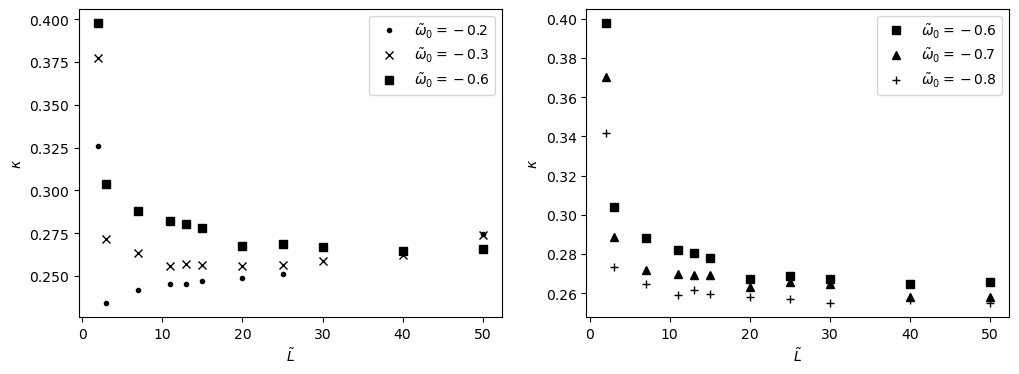

In [173]:
fig = plt.figure(figsize = (12, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(L_array, kappa_array[1], '.', color = 'black', label = r'$\tilde{\omega}_0 = -0.2$')
ax1.plot(L_array, kappa_array[2], 'x', color = 'black', label = r'$\tilde{\omega}_0 = -0.3$')
ax1.plot(L_array, kappa_array[5], 's', color = 'black', label = r'$\tilde{\omega}_0 = -0.6$')
ax1.set_xlabel(r'$\tilde{L}$')
ax1.set_ylabel(r'$\kappa$')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(L_array, kappa_array[5], 's', color = 'black', label = r'$\tilde{\omega}_0 = -0.6$')
ax2.plot(L_array, kappa_array[6], '^', color = 'black', label = r'$\tilde{\omega}_0 = -0.7$')
ax2.plot(L_array, kappa_array[7], '+',color = 'black', label = r'$\tilde{\omega}_0 = -0.8$')
ax2.set_xlabel(r'$\tilde{L}$')
ax2.set_ylabel(r'$\kappa$')
ax2.legend()


fig.savefig('kappa_comp')